In [ ]:
import requests
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [ ]:
#  TASK 1: EXTRACT

API_KEY = "b46fa93be5947e7e9d687b8754f97f15"

cities = ["Lagos", "London", "New York"]

In [ ]:
weather_data = []

for city in cities:
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    data = response.json()

    if data.get('cod') == 200:
        now = datetime.now()
        weather_data.append({
            "City": data["name"],
            "Temperature": data["main"]["temp"],
            "Humidity": data["main"]["humidity"],
            "Condition": data["weather"][0]["main"],
            "Wind": data["wind"]["speed"],
            "Date": now.strftime("%Y-%m-%d"),
            "Time": now.strftime("%H:%M:%S")
        })
        print(f"Got data for {city}")
    else:
        print(f"Error for {city}:", data.get("message"))

print("\nRaw data:")
print(weather_data)

Got data for Lagos
Got data for London
Got data for New York

Raw data:
[{'City': 'Lagos', 'Temperature': 27.62, 'Humidity': 78, 'Condition': 'Rain', 'Wind': 2.64, 'Date': '2026-06-20', 'Time': '09:29:09'}, {'City': 'London', 'Temperature': 22.27, 'Humidity': 73, 'Condition': 'Clouds', 'Wind': 0.89, 'Date': '2026-06-20', 'Time': '09:29:09'}, {'City': 'New York', 'Temperature': 19.5, 'Humidity': 60, 'Condition': 'Clear', 'Wind': 8.49, 'Date': '2026-06-20', 'Time': '09:29:09'}]


In [ ]:
#  TASK 2: TRANSFORM

import pandas as pd

# Create DataFrame from the list we built
df = pd.DataFrame(weather_data)

# Rename columns to match the assignment requirements
df.columns = ["City", "Temp_C", "Humidity_%", "Condition", "Wind_m/s", "Date", "Time"]

# Fix data types - make sure numbers are actually numbers
df["Temp_C"] = df["Temp_C"].astype(float)
df["Humidity_%"] = df["Humidity_%"].astype(int)
df["Wind_m/s"] = df["Wind_m/s"].astype(float)

# Show the clean table
print("Cleaned dataset:")
print(df)

Cleaned dataset:
       City  Temp_C  Humidity_% Condition  Wind_m/s        Date      Time
0     Lagos   27.62          78      Rain      2.64  2026-06-20  09:29:09
1    London   22.27          73    Clouds      0.89  2026-06-20  09:29:09
2  New York   19.50          60     Clear      8.49  2026-06-20  09:29:09


In [ ]:
#  TASK 3: LOAD

df.to_csv("weather_data.csv", index=False)
print("Saved! Check your folder for weather_data.csv")

Saved! Check your folder for weather_data.csv


In [ ]:
# TASK 4: BASIC ANALYSIS


# Read the CSV we just saved
df = pd.read_csv("weather_data.csv")

print("=== ANALYSIS RESULTS ===")

# 1. Average temperature across all cities
avg_temp = df["Temp_C"].mean()
print(f"1. Average Temperature: {avg_temp:.2f}°C")

# 2. City with highest humidity
max_humidity_city = df.loc[df["Humidity_%"].idxmax(), "City"]
max_humidity_val = df["Humidity_%"].max()
print(f"2. Highest Humidity: {max_humidity_city} with {max_humidity_val}%")

# 3. Weather conditions and corresponding cities
print("3. Weather Condition Counts and Cities:")
grouped_conditions = df.groupby('Condition')['City'].apply(list)
for condition, cities_list in grouped_conditions.items():
    print(f"- {condition}: {', '.join(cities_list)}")

# 4. Hottest city - added
hottest_city = df.loc[df["Temp_C"].idxmax(), "City"]
hottest_temp = df["Temp_C"].max()
print(f"4. Hottest City: {hottest_city} with {hottest_temp}°C")

=== ANALYSIS RESULTS ===
1. Average Temperature: 23.13°C
2. Highest Humidity: Lagos with 78%
3. Weather Condition Counts and Cities:
- Clear: New York
- Clouds: London
- Rain: Lagos
4. Hottest City: Lagos with 27.62°C


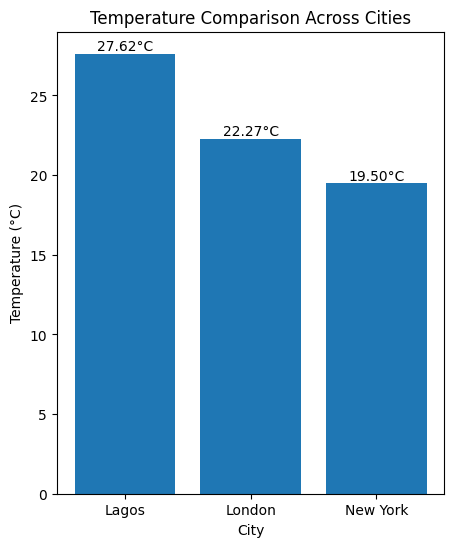

In [ ]:
# TASK 5: VISUALIZATION (TEMPERATURE COMPARISON)

import matplotlib.pyplot as plt

plt.figure(figsize=(5,6))

plt.bar(df["City"], df["Temp_C"])

plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")

for i, value in enumerate(df["Temp_C"]):
    plt.text(i, value + 0.2, f"{value:.2f}°C", ha='center')

plt.show()

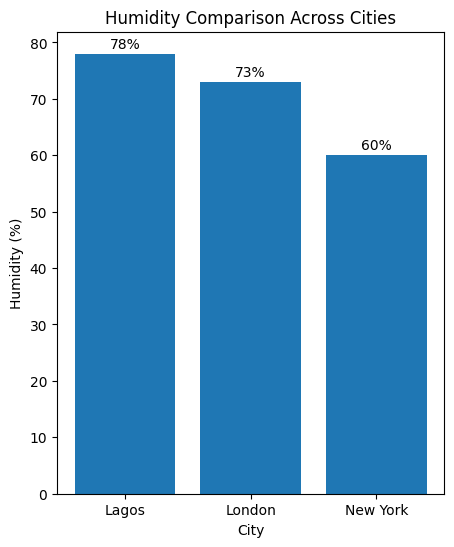

In [ ]:
# ===== TASK 6: VISUALIZATION (HUMIDITY COMPARISON) =====


import matplotlib.pyplot as plt

plt.figure(figsize=(5,6))

plt.bar(df["City"], df["Humidity_%"])

plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")

for i, value in enumerate(df["Humidity_%"]):
    plt.text(i, value + 1, f"{value}%", ha='center')

plt.show()

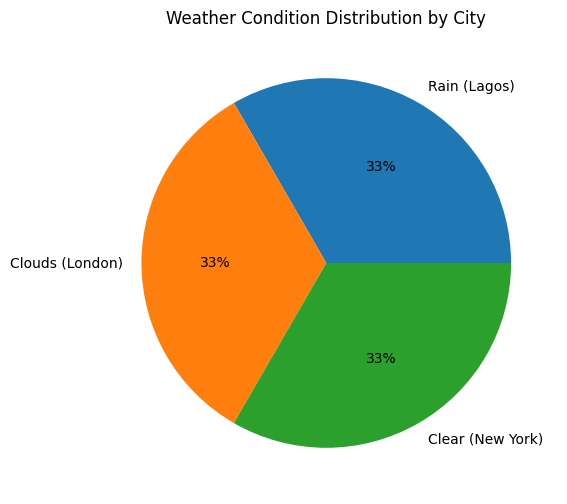

In [ ]:
#  TASK 7: VISUALIZATION (WEATHER CONDITION DISTRIBUTION BY CITY)


weather_counts = df["Condition"].value_counts()

# Create a mapping from Condition to City for labeling
condition_city_map = df.set_index('Condition')['City'].to_dict()

# Create new labels combining condition and city
new_labels = [f"{condition} ({condition_city_map.get(condition, 'N/A')})" for condition in weather_counts.index]

plt.figure(figsize=(6,6))

plt.pie(
    weather_counts,
    labels=new_labels,  # Use the new labels
    autopct='%1.0f%%'
)

plt.title("Weather Condition Distribution by City")

plt.show()

**CONCLUSION**

For this task, I built an ETL pipeline using Python to extract weather data from the OpenWeatherMap API for Lagos, London, and New York. The extraction step pulled real-time temperature, humidity, weather condition, and wind speed, and I added Date and Time fields using datetime. In the transformation step, I converted the data into a Pandas DataFrame, renamed columns for clarity, and set correct data types. The cleaned data was then loaded into weather_data.csv. Analysis of the dataset showed an average temperature of 23.13°C across all cities. The city with the highest humidity was Lagos at 78%. The weather condition in London is Cloudy,the weather condition in Lagos is Rainy while the weather condition in New York is Clear. The hottest city was Lagos at 27.62°C. This project demonstrated how ETL processes can be used to automate data collection and prepare it for analysis.